# Region-dependent 2D infiltration from a soil map

Sets up **spatially varying infiltration of the 2D surface** on the model built by
`template.ipynb`, so that direct rainfall on the 2D grid infiltrates at a rate that
depends on the soil type of each region - **without any hydrological (rainfall-runoff)
model**. This is D-Flow FM's own 2D infiltration, not the D-HYDAMO DRR concept.

## How it works

D-Flow FM infiltrates rain per 2D cell when the `[grw]` section sets
`Infiltrationmodel = 2` (*constant infiltration capacity*). The capacity can be made
spatially varying by supplying an `infiltrationcapacity` field through the **old-style**
external-forcing file (`ExtForceFile`), which happily coexists with the new-style
`ExtForceFileNew = bnd.ext` the template already uses for boundaries and rainfall.

So the soil map is turned into a per-cell capacity exactly the way `sobek_soil.tif`
drives the *RR* unpaved nodes in `template.ipynb` - but routed to the 2D kernel instead:

1. **soil classes -> capacity** via a lookup (sand / loam / clay).
2. **sample per 2D face** (`mesh2d_face_x/y` from `network.nc`, like `roughness.arl`
   samples net-links) and write an `.xyz` sample - guarantees every cell gets a value.
3. reference it from `infiltration.ext` (`QUANTITY=infiltrationcapacity`) and switch on
   `[grw] Infiltrationmodel = 2` in `DFM.mdu`.

Everything is done **post-build** by editing the exported `delft3d_model/dflowfm/` files
directly (the `trachytopes.ipynb` pattern), so the model does not have to be rebuilt.

> **Units.** The spatial `infiltrationcapacity` field is in **mm/hr** (verified below by
> the run: if it were m/s even clay would drain instantly and the regions would be
> identical). Note this differs from the *uniform* `UnifInfiltrationCapacity` MDU key,
> which the manual documents in m/s.

## What this notebook proves

It runs the exported model **twice under identical rainfall** - infiltration off, then on -
and compares the total 2D water volume and the per-region infiltrated depth. Less ponding
with infiltration on, ordered sand > loam > clay, means it works.

> Run `template.ipynb` first so `delft3d_model` and its `network.nc` exist.

In [1]:
from pathlib import Path
import shutil
import subprocess

import matplotlib.pyplot as plt
import numpy as np
import rasterio
from rasterio.transform import from_origin
import xarray as xr

import geopandas as gpd

# The template model must have been exported first (template.ipynb).
data_path = Path("../tests/data/template/datasets").resolve()
output_path = data_path / "delft3d_model"
dfm_dir = output_path / "dflowfm"
soil_file = data_path / "rasters" / "soil_map.tif"       # sample soil map (created below)

assert dfm_dir.exists(), "Run template.ipynb first to export delft3d_model"
assert (dfm_dir / "network.nc").exists(), "network.nc missing - re-export the model"

# soil class -> infiltration capacity [mm/hr]. Higher = more permeable.
CAP_LOOKUP = {1: 20.0, 2: 5.0, 3: 1.0}   # 1=sand, 2=loam, 3=clay
DEFAULT_CAP = 5.0                         # fallback where the soil map has no data
SOIL_NAMES = {1: "sand", 2: "loam", 3: "clay"}

print("model dir :", dfm_dir)

model dir : G:\workspace\github\HYDROLIB\hydrolib\tests\data\template\datasets\delft3d_model\dflowfm


## Sample soil map

A categorical soil raster covering the 2D extent, split into three regions (sand / loam /
clay) so infiltration visibly varies across the domain - the role `sobek_soil.tif` plays
for the RR unpaved nodes. Generated into `rasters/soil_map.tif` if it is not already
there, so the notebook is self-contained and reproducible.

using existing G:\workspace\github\HYDROLIB\hydrolib\tests\data\template\datasets\rasters\soil_map.tif


C:\Users\Hi\AppData\Local\Temp\ipykernel_7432\1838208700.py:30: DeprecationWarning: Setting the shape on a NumPy array has been deprecated in NumPy 2.5.
As an alternative, you can create a new view using np.reshape (with copy=False if needed).
  soil = src.read(1)


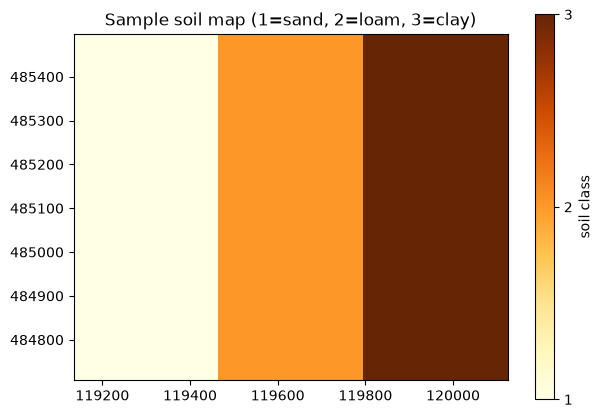

In [2]:
def make_soil_map(soil_file, extent_shp, cellsize=10.0, pad=20.0):
    """Write a 3-region categorical soil map (1=sand west, 2=loam mid, 3=clay east)
    covering the 2D extent. Vertical bands keep the regions obvious on a map."""
    minx, miny, maxx, maxy = gpd.read_file(extent_shp).total_bounds
    minx -= pad; miny -= pad; maxx += pad; maxy += pad
    ncol = int(np.ceil((maxx - minx) / cellsize))
    nrow = int(np.ceil((maxy - miny) / cellsize))
    transform = from_origin(minx, miny + nrow * cellsize, cellsize, cellsize)

    xcenters = minx + (np.arange(ncol) + 0.5) * cellsize
    band = np.ones(ncol, dtype=np.uint8)                       # west third -> 1 (sand)
    band[xcenters > minx + (maxx - minx) / 3] = 2              # middle    -> 2 (loam)
    band[xcenters > minx + 2 * (maxx - minx) / 3] = 3          # east third-> 3 (clay)
    soil = np.tile(band, (nrow, 1))

    soil_file.parent.mkdir(parents=True, exist_ok=True)
    with rasterio.open(soil_file, "w", driver="GTiff", height=nrow, width=ncol, count=1,
                       dtype="uint8", crs="EPSG:28992", transform=transform, nodata=0) as dst:
        dst.write(soil, 1)
    return soil


if not soil_file.exists():
    make_soil_map(soil_file, data_path / "2D_extent.shp")
    print("created", soil_file)
else:
    print("using existing", soil_file)

with rasterio.open(soil_file) as src:
    soil = src.read(1)
    bounds = src.bounds
fig, ax = plt.subplots(figsize=(7, 5))
im = ax.imshow(soil, extent=(bounds.left, bounds.right, bounds.bottom, bounds.top),
               origin="upper", cmap="YlOrBr")
ax.set_title("Sample soil map (1=sand, 2=loam, 3=clay)")
ax.set_aspect("equal")
fig.colorbar(im, ax=ax, ticks=[1, 2, 3], label="soil class")
plt.show()

## Write the infiltration-capacity field

Reclassify the soil map to a capacity per 2D face, sampled at the face centres read from
`network.nc`, and write it as an `.xyz` sample plus the old-style ext file that points at
it. `FILETYPE=7` (samples) + `METHOD=6` (averaging, `AVERAGINGTYPE=1` mean) makes the
kernel pick each cell's own sample.

In [3]:
def write_infiltration_field(dfm_dir, soil_file, cap_lookup, default_cap):
    """Write infiltcap.xyz (per 2D face) and infiltration.ext into the model dir.

    The capacity of each face is looked up from the soil class sampled at the face
    centre, so the field follows the soil map region by region.
    """
    dfm_dir = Path(dfm_dir)
    with xr.open_dataset(dfm_dir / "network.nc") as ds:
        fx = ds["mesh2d_face_x"].values
        fy = ds["mesh2d_face_y"].values

    with rasterio.open(soil_file) as src:
        classes = np.array(list(src.sample(np.column_stack([fx, fy]))), dtype=float).ravel()

    cap = np.full(fx.shape, default_cap, dtype=float)
    for cls, val in cap_lookup.items():
        cap[classes == cls] = val

    # one sample point per 2D face centre: x y capacity[mm/hr]
    (dfm_dir / "infiltcap.xyz").write_text(
        "\n".join(f"{x:.3f} {y:.3f} {c:.4f}" for x, y, c in zip(fx, fy, cap)) + "\n"
    )
    # old-style external forcing: spatial infiltration capacity, samples + averaging
    (dfm_dir / "infiltration.ext").write_text(
        "QUANTITY=infiltrationcapacity\n"
        "FILENAME=infiltcap.xyz\n"
        "FILETYPE=7\n"          # 7 = samples (.xyz)
        "METHOD=6\n"            # 6 = averaging in space
        "OPERAND=O\n"           # overwrite
        "AVERAGINGTYPE=1\n"     # 1 = simple mean (each cell gets its own sample)
        "RELATIVESEARCHCELLSIZE=1.01\n"
    )
    return classes, cap


classes, cap = write_infiltration_field(dfm_dir, soil_file, CAP_LOOKUP, DEFAULT_CAP)
uniq, counts = np.unique(cap, return_counts=True)
print(f"wrote infiltcap.xyz + infiltration.ext ({cap.size} 2D faces)")
for v, n in zip(uniq, counts):
    print(f"  {n:5d} faces at {v:5.1f} mm/hr")

wrote infiltcap.xyz + infiltration.ext (4991 2D faces)
    781 faces at   1.0 mm/hr
   2491 faces at   5.0 mm/hr
   1719 faces at  20.0 mm/hr


## Toggle infiltration in the MDU

`enable_infiltration` inserts a `[grw]` section (`Infiltrationmodel = 2`) and wires the old
ext file into `[External Forcing]`; `disable_infiltration` strips both, returning the model
to its exported (no-infiltration) state. Both are idempotent - they clear any previous
`[grw]`/old-`ExtForceFile` first - so the two runs below are clean opposites.

In [4]:
def _strip_infiltration(lines):
    """Remove any [grw] section and any old-style ExtForceFile line."""
    out, skip_grw = [], False
    for ln in lines:
        s = ln.strip().lower()
        if s == "[grw]":
            skip_grw = True
            continue
        if skip_grw:
            if s.startswith("["):          # next section ends [grw]
                skip_grw = False
            else:
                continue
        if s.startswith("extforcefile") and "new" not in s:
            continue                        # drop old-style ExtForceFile
        out.append(ln)
    return out


def disable_infiltration(dfm_dir):
    """Baseline: no [grw], no old ExtForceFile (model's exported state)."""
    mdu = Path(dfm_dir) / "DFM.mdu"
    mdu.write_text("\n".join(_strip_infiltration(mdu.read_text().splitlines())) + "\n")


def enable_infiltration(dfm_dir, extfile="infiltration.ext"):
    """Switch on constant-capacity 2D infiltration driven by the spatial field."""
    mdu = Path(dfm_dir) / "DFM.mdu"
    lines = _strip_infiltration(mdu.read_text().splitlines())

    # set ExtForceFile inside the existing [External Forcing] section
    out, in_ef, done = [], False, False
    for ln in lines:
        s = ln.strip().lower()
        if s == "[external forcing]":
            in_ef = True
        elif s.startswith("[") and in_ef:
            out.append(f"extForceFile    = {extfile}")
            in_ef, done = False, True
        out.append(ln)
    if in_ef and not done:
        out.append(f"extForceFile    = {extfile}")

    # append the [grw] section
    out += ["", "[grw]", "GroundWater        = 0", "Infiltrationmodel  = 2"]
    mdu.write_text("\n".join(out) + "\n")


enable_infiltration(dfm_dir)
print("infiltration enabled ([grw] Infiltrationmodel=2, ExtForceFile=infiltration.ext)")

infiltration enabled ([grw] Infiltrationmodel=2, ExtForceFile=infiltration.ext)


## Rain and simulation window

Infiltration only does something when it actually rains on the 2D grid, and the template
ships a *dry* `rainfall.bc`. `apply_rain` writes a block event (`name=global`, the spelling
the `[Meteo]` block expects) straight over `dflowfm/rainfall.bc`, exactly like
`rainfall.ipynb`. `set_sim_window` shortens `Tstop` (and aligns the map-output end) so the
two demo runs are quick; drop it to keep the model's full 48 h window.

In [5]:
def apply_rain(dfm_dir, intensity_mm_h, duration_h, refdate_str="2016-06-01 00:00:00"):
    """Overwrite rainfall.bc with a block event: constant rain then dry."""
    end = duration_h * 60.0
    mmday = intensity_mm_h * 24.0                     # D-Flow FM wants mm/day
    (Path(dfm_dir) / "rainfall.bc").write_text(
        "[General]\nfileVersion = 1.01\nfileType    = boundConds\n\n"
        "[Forcing]\nname              = global\nfunction          = timeseries\n"
        "timeInterpolation = block-To\n"
        f"quantity = time\nunit     = minutes since {refdate_str}\n"
        "quantity = rainfall\nunit     = mm day-1\n"
        f"0.0    {mmday:.1f}\n{end:.1f}    {mmday:.1f}\n{end:.1f}    0.0\n"
    )


def set_sim_window(dfm_dir, hours):
    """Set Tstop and the map-output end time to `hours` (keeps map file free of fill)."""
    mdu = Path(dfm_dir) / "DFM.mdu"
    secs = hours * 3600.0
    out = []
    for ln in mdu.read_text().splitlines():
        key = ln.split("=")[0].strip().lower()
        cmt = ("#" + ln.split("#", 1)[1]) if "#" in ln else ""
        if key == "tstop":
            ln = f"tStop                   = {secs:<8.1f}{cmt}"
        elif key == "mapinterval":
            interval = ln.split("=")[1].split()[0]
            ln = f"mapInterval                       = {interval} 0.0 {secs:.1f} {cmt}"
        out.append(ln)
    mdu.write_text("\n".join(out) + "\n")


DEMO_HOURS = 6.0
set_sim_window(dfm_dir, DEMO_HOURS)
apply_rain(dfm_dir, intensity_mm_h=50.0, duration_h=2.0)    # 50 mm/h for 2 h, then dry
print(f"window = {DEMO_HOURS:.0f} h, rain = 50 mm/h for 2 h")

window = 6 h, rain = 50 mm/h for 2 h


## Run with and without infiltration

Runs the exported model through `run.bat` (the DIMR/D-Flow FM kernel wired up by
`template.ipynb`), once with infiltration **off** and once **on**, under the same rain.
Each run's `output/` is copied aside so both are kept for comparison.

In [6]:
def run_model(model_dir, tag):
    """Run run.bat and copy dflowfm/output -> dflowfm/output_<tag>. Returns the map file."""
    model_dir = Path(model_dir)
    out_live = model_dir / "dflowfm" / "output"
    if out_live.exists():
        shutil.rmtree(out_live)
    out_live.mkdir(parents=True)

    # full path to run.bat: cmd will not find the bare name even with cwd set.
    proc = subprocess.run(["cmd", "/c", str(model_dir / "run.bat")], cwd=model_dir,
                          capture_output=True, text=True)
    if proc.returncode != 0:
        print(proc.stdout[-2000:]); print(proc.stderr[-2000:])
        raise RuntimeError(f"run '{tag}' failed (exit {proc.returncode})")

    saved = model_dir / "dflowfm" / f"output_{tag}"
    if saved.exists():
        shutil.rmtree(saved)
    shutil.copytree(out_live, saved)
    return saved / "DFM_map.nc"


# infiltration OFF (baseline)
disable_infiltration(dfm_dir)
map_off = run_model(output_path, "noinfil")
print("baseline (no infiltration) done ->", map_off.name)

# infiltration ON (spatial soil-map capacity)
enable_infiltration(dfm_dir)
map_on = run_model(output_path, "infil")
print("infiltration run done         ->", map_on.name)

baseline (no infiltration) done -> DFM_map.nc


infiltration run done         -> DFM_map.nc


## Compare: total 2D water volume

Same rain in both runs, so any persistent gap is water the ground took up. Map files carry
fill values for output times beyond `Tstop`, so only the written steps are used.

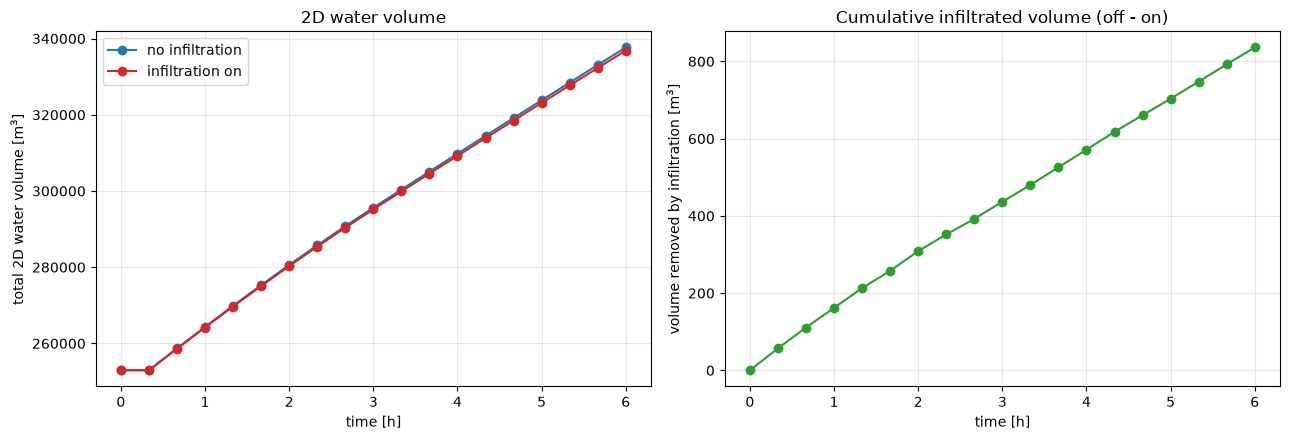

final volume  off : 337,668.4 m3
final volume  on  : 336,832.3 m3
infiltrated (off-on): 836.1 m3


In [7]:
def volume_series(map_nc):
    """Total 2D water volume (sum of depth x cell area) at each written map time."""
    with xr.open_dataset(map_nc, decode_times=False) as m:
        wd = m["mesh2d_waterdepth"].values          # (time, face)
        ba = m["mesh2d_flowelem_ba"].values          # cell areas
        t = m["time"].values
    valid = [i for i in range(wd.shape[0]) if np.isfinite(wd[i]).any()]
    return np.array([t[i] for i in valid]), np.array([np.nansum(wd[i] * ba) for i in valid])


t_off, v_off = volume_series(map_off)
t_on, v_on = volume_series(map_on)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5))
ax1.plot(t_off / 3600, v_off, "-o", label="no infiltration", color="#1f77b4")
ax1.plot(t_on / 3600, v_on, "-o", label="infiltration on", color="#d62728")
ax1.set_xlabel("time [h]"); ax1.set_ylabel("total 2D water volume [m$^3$]")
ax1.set_title("2D water volume"); ax1.legend(); ax1.grid(alpha=0.3)

ax2.plot(t_off / 3600, v_off - v_on, "-o", color="#2ca02c")
ax2.set_xlabel("time [h]"); ax2.set_ylabel("volume removed by infiltration [m$^3$]")
ax2.set_title("Cumulative infiltrated volume (off - on)"); ax2.grid(alpha=0.3)
plt.tight_layout(); plt.show()

print(f"final volume  off : {v_off[-1]:,.1f} m3")
print(f"final volume  on  : {v_on[-1]:,.1f} m3")
print(f"infiltrated (off-on): {v_off[-1] - v_on[-1]:,.1f} m3")

## Compare: infiltration per soil region

The point of the soil map is that regions differ. The per-face water-depth difference
(off - on) x area is the volume each cell took up; grouped by soil class it should order
**sand > loam > clay**, tracking the capacity lookup.

sand  (cap   20 mm/hr):    485.9 m3, mean depth 3.200 mm
loam  (cap    5 mm/hr):    319.6 m3, mean depth 2.076 mm
clay  (cap    1 mm/hr):     30.5 m3, mean depth 0.901 mm


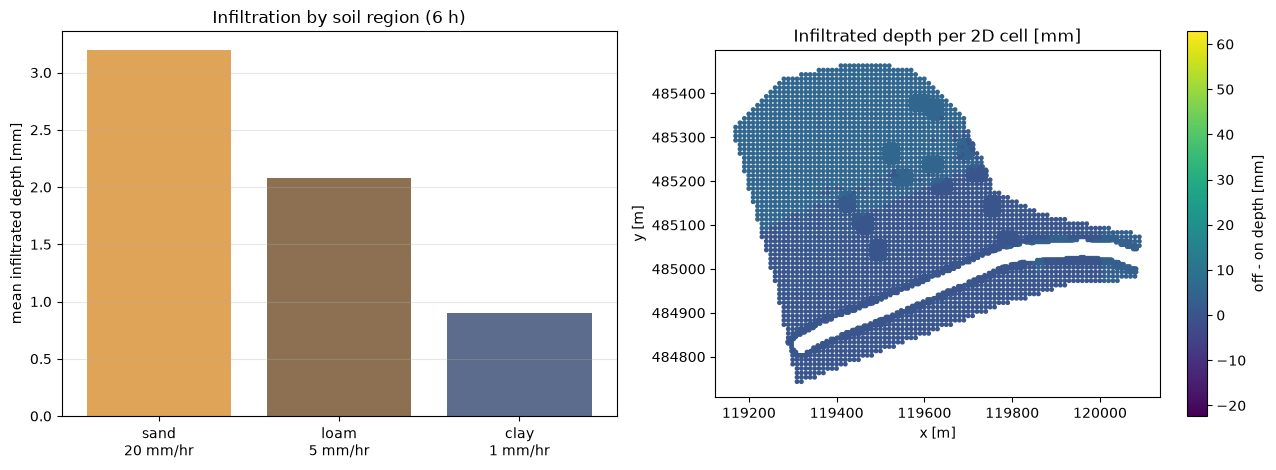

In [8]:
def final_depth(map_nc):
    with xr.open_dataset(map_nc, decode_times=False) as m:
        wd = m["mesh2d_waterdepth"].values
        ba = m["mesh2d_flowelem_ba"].values
        fx = m["mesh2d_face_x"].values; fy = m["mesh2d_face_y"].values
    valid = [i for i in range(wd.shape[0]) if np.isfinite(wd[i]).any()]
    return wd[valid[-1]], ba, fx, fy


d_off, ba, fx, fy = final_depth(map_off)
d_on, _, _, _ = final_depth(map_on)
dvol = (d_off - d_on) * ba                            # infiltrated volume per face [m3]

with rasterio.open(soil_file) as src:
    face_cls = np.array(list(src.sample(np.column_stack([fx, fy]))), dtype=float).ravel()

labels, depths, vols = [], [], []
for cls in sorted(CAP_LOOKUP):
    mask = face_cls == cls
    vol = np.nansum(dvol[mask])
    depth_mm = vol / np.nansum(ba[mask]) * 1000.0     # mean infiltrated depth [mm]
    labels.append(f"{SOIL_NAMES[cls]}\n{CAP_LOOKUP[cls]:.0f} mm/hr")
    depths.append(depth_mm); vols.append(vol)
    print(f"{SOIL_NAMES[cls]:5s} (cap {CAP_LOOKUP[cls]:4.0f} mm/hr): "
          f"{vol:8.1f} m3, mean depth {depth_mm:.3f} mm")

fig, (axb, axm) = plt.subplots(1, 2, figsize=(13, 4.8))
axb.bar(labels, depths, color=["#e0a458", "#8c7051", "#5b6c8c"])
axb.set_ylabel("mean infiltrated depth [mm]")
axb.set_title(f"Infiltration by soil region ({DEMO_HOURS:.0f} h)")
axb.grid(axis="y", alpha=0.3)

sc = axm.scatter(fx, fy, c=(d_off - d_on) * 1000.0, s=6, cmap="viridis")
axm.set_aspect("equal"); axm.set_title("Infiltrated depth per 2D cell [mm]")
axm.set_xlabel("x [m]"); axm.set_ylabel("y [m]")
fig.colorbar(sc, ax=axm, label="off - on depth [mm]")
plt.tight_layout(); plt.show()

## Result

If the bars order sand > loam > clay and the map shows more infiltration in the west
(sandy) band, region-dependent 2D infiltration from the soil map is working - driven purely
by D-Flow FM's `[grw]` model, with no rainfall-runoff model involved.

To go back to the plain model, run `disable_infiltration(dfm_dir)` (and re-run
`template.ipynb` to restore the original 48 h window and dry rainfall).